In [2]:
# Celda 1 — Instalar dependencias y montar Drive
!pip install wandb -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from google.colab import drive
import pickle
from google.colab import userdata
import wandb
from google.colab import userdata
import warnings

wandb.login(key=userdata.get('WANDB_API_KEY'))

warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("Setup completado.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Mounted at /content/drive
Setup completado.


In [3]:
# Celda 2 — Cargar splits desde Drive
X_train = np.load(DRIVE_PATH + "X_train.npy")
X_val   = np.load(DRIVE_PATH + "X_val.npy")
X_test  = np.load(DRIVE_PATH + "X_test.npy")
y_train = np.load(DRIVE_PATH + "y_train.npy")
y_val   = np.load(DRIVE_PATH + "y_val.npy")
y_test  = np.load(DRIVE_PATH + "y_test.npy")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (350000, 28), Val: (75000, 28), Test: (75000, 28)


In [4]:
# Celda 3 — Función de evaluación (5-Fold CV, scaler por fold)
def evaluar_modelo_cv(model, X_train, y_train, X_val, y_val, X_test, y_test,
                      nombre, k=5):
    """
    Entrena modelo con K-Fold CV sobre train. Scaler se ajusta
    dentro de cada fold para evitar leakage. Reporta AUC-ROC/F1/Accuracy
    con intervalos de confianza (media ± 2σ) en train CV, val y test.
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    auc_folds, f1_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

    for tr_idx, vl_idx in kf.split(X_train, y_train):
        scaler_cv = StandardScaler()
        X_tr_fold = scaler_cv.fit_transform(X_train[tr_idx])
        X_vl_fold = scaler_cv.transform(X_train[vl_idx])
        model.fit(X_tr_fold, y_train[tr_idx])
        y_prob = model.predict_proba(X_vl_fold)[:, 1]
        y_pred = model.predict(X_vl_fold)
        auc_folds.append(roc_auc_score(y_train[vl_idx], y_prob))
        f1_folds.append(f1_score(y_train[vl_idx], y_pred))
        acc_folds.append(accuracy_score(y_train[vl_idx], y_pred))
        prec_folds.append(precision_score(y_train[vl_idx], y_pred))
        rec_folds.append(recall_score(y_train[vl_idx], y_pred))

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)
    model.fit(X_train_sc, y_train)

    return {
        "Modelo": nombre,
        "AUC_CV_mean": np.mean(auc_folds),
        "AUC_CV_std":  np.std(auc_folds),
        "F1_CV_mean":  np.mean(f1_folds),
        "F1_CV_std":   np.std(f1_folds),
        "Acc_CV_mean": np.mean(acc_folds),
        "Acc_CV_std":  np.std(acc_folds),
        "Precision_CV_mean": np.mean(prec_folds),
        "Precision_CV_std":  np.std(prec_folds),
        "Recall_CV_mean": np.mean(rec_folds),
        "Recall_CV_std":  np.std(rec_folds),
        "AUC_val": roc_auc_score(y_val,  model.predict_proba(X_val_sc)[:, 1]),
        "F1_val":  f1_score(y_val,  model.predict(X_val_sc)),
        "Acc_val": accuracy_score(y_val, model.predict(X_val_sc)),
        "Precision_val": precision_score(y_val, model.predict(X_val_sc)),
        "Recall_val": recall_score(y_val, model.predict(X_val_sc)),
        "AUC_test": roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
        "F1_test":  f1_score(y_test,  model.predict(X_test_sc)),
        "Acc_test": accuracy_score(y_test, model.predict(X_test_sc)),
        "Precision_test": precision_score(y_test, model.predict(X_test_sc)),
        "Recall_test": recall_score(y_test, model.predict(X_test_sc)),
        "_scaler": scaler,
        "_model": model,
    }


def tabla_resultados(resultados_lista):
    """Formatea lista de resultados como DataFrame con IC."""
    rows = []
    for r in resultados_lista:
        rows.append({
            "Modelo": r["Modelo"],
            "AUC CV (mean±2σ)": f"{r['AUC_CV_mean']:.3f} ± {2*r['AUC_CV_std']:.3f}",
            "AUC Val":  f"{r['AUC_val']:.3f}",
            "AUC Test": f"{r['AUC_test']:.3f}",
            "F1 Test":  f"{r['F1_test']:.3f}",
            "Acc Test": f"{r['Acc_test']:.3f}",
            "Precision Test": f"{r['Precision_test']:.3f}",
            "Recall Test": f"{r['Recall_test']:.3f}",
        })
    return pd.DataFrame(rows).set_index("Modelo")

Entrenando KNN sobre submuestra de 100K...
Submuestra KNN: (100000, 28)
  k= 3: AUC val = 0.6431
  k= 5: AUC val = 0.6633
  k=10: AUC val = 0.6834
  k=15: AUC val = 0.6940
  k=25: AUC val = 0.7039


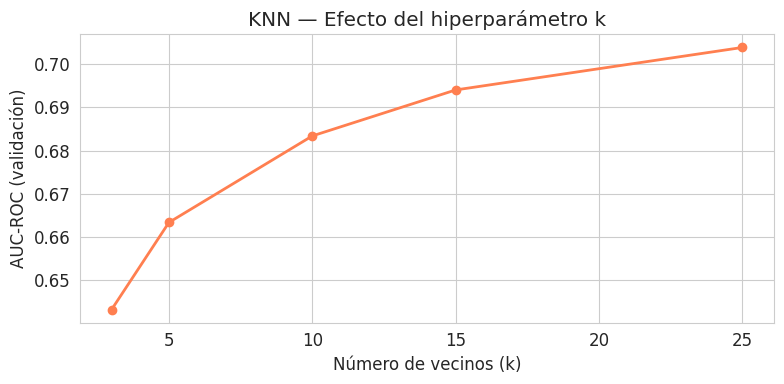


Mejor k: 25


AUC_CV_2std,▁
AUC_CV_mean,▁
AUC_test,▁
AUC_val,▁▃▆▇██
Acc_test,▁
F1_test,▁
k,▁▂▃▅█
AUC_CV_2std,0.00249
AUC_CV_mean,0.70123
AUC_test,0.7058
AUC_val,0.70389


In [5]:
# Celda 4 — KNN (modelo no paramétrico)
nombre_modelo = "KNN"

wandb.init(project="higgs-boson", name="KNN", config={"n_neighbors_grid": [3, 5, 10, 15, 25], "subsample": 100000})
print(f"Entrenando {nombre_modelo} sobre submuestra de 100K...")

X_knn, _, y_knn, _ = train_test_split(X_train, y_train, train_size=100_000,
                                       stratify=y_train, random_state=42)
print(f"Submuestra KNN: {X_knn.shape}")

param_grid_knn = {"n_neighbors": [3, 5, 10, 15, 25]}
auc_por_k = []

scaler_knn = StandardScaler()
X_knn_sc = scaler_knn.fit_transform(X_knn)
X_val_sc  = scaler_knn.transform(X_val)

for k in param_grid_knn["n_neighbors"]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_knn_sc, y_knn)
    auc = roc_auc_score(y_val, knn.predict_proba(X_val_sc)[:, 1])
    auc_por_k.append(auc)
    wandb.log({"k": k, "AUC_val": auc})
    print(f"  k={k:2d}: AUC val = {auc:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(param_grid_knn["n_neighbors"], auc_por_k, "o-", color="coral", linewidth=2)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("AUC-ROC (validación)")
plt.title("KNN — Efecto del hiperparámetro k")
plt.grid(True)
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_knn_hiperparametro.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = param_grid_knn["n_neighbors"][int(np.argmax(auc_por_k))]
print(f"\nMejor k: {best_k}")
nombre_modelo = f"KNN (k={best_k}, 100K)"

knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
result = evaluar_modelo_cv(knn_best, X_knn, y_knn, X_val, y_val,
                            X_test, y_test, nombre_modelo)

# Log final metrics to wandb
wandb.log({
    "AUC_CV_mean": result["AUC_CV_mean"],
    "AUC_CV_2std": 2 * result["AUC_CV_std"],
    "AUC_val": result["AUC_val"],
    "AUC_test": result["AUC_test"],
    "F1_test": result["F1_test"],
    "Acc_test": result["Acc_test"],
})
wandb.finish()


In [6]:
# Celda 5 — Guardar resultado y modelo
df_result = tabla_resultados([result])
print(df_result.to_string())

# Guardar CSV para ensamblaje final
safe_name = nombre_modelo.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
df_result.to_csv(DRIVE_PATH + f"resultado_{safe_name}.csv")

# Guardar modelo pickle
with open(DRIVE_PATH + f"modelo_{safe_name}.pkl", "wb") as f:
    pickle.dump({"model": result["_model"], "scaler": result["_scaler"]}, f)

print(f"\nArtefactos guardados: resultado_{safe_name}.csv + modelo_{safe_name}.pkl")

                 AUC CV (mean±2σ) AUC Val AUC Test F1 Test Acc Test Precision Test Recall Test
Modelo                                                                                        
KNN (k=25, 100K)    0.701 ± 0.002   0.704    0.706   0.701    0.652          0.644       0.770

Artefactos guardados: resultado_KNN_k25_100K.csv + modelo_KNN_k25_100K.pkl
